In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os

from torch.utils.data import Dataset
import random
from PIL import Image

import torch.nn as nn
from torchvision import models
import torch.nn.functional as F

In [13]:

    
# Define transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load dataset
dataset_type = 'large'
data_dir = 'Dataset1/images'
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split sizes
total_len = len(dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

# Split dataset
train_data, val_data, test_data = random_split(dataset, [train_len, val_len, test_len])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# Class mapping
class_names = dataset.classes
print("Classes:", class_names)


Classes: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012']


In [14]:


class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=512):
        super(EmbeddingNet, self).__init__()
        self.base_model = models.resnet18(pretrained=True)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, embedding_dim)

    def forward(self, x):
        return self.base_model(x)


class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive)
        neg_dist = F.pairwise_distance(anchor, negative)
        loss = torch.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()




In [15]:
class TripletDataset(Dataset):
    def __init__(self, image_folder_dataset, transform=None):
        self.dataset = image_folder_dataset
        self.transform = transform

        # Build a dict of {class_idx: list of image indices}
        self.class_to_indices = {}
        for idx, (_, label) in enumerate(self.dataset.samples):
            self.class_to_indices.setdefault(label, []).append(idx)

    def __getitem__(self, index):
        anchor_img, anchor_label = self.dataset[index]

        # Select a positive example (same class)
        positive_idx = index
        while positive_idx == index:
            positive_idx = random.choice(self.class_to_indices[anchor_label])
        positive_img, _ = self.dataset[positive_idx]

        # Select a negative example (different class)
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = random.choice(list(self.class_to_indices.keys()))
        negative_idx = random.choice(self.class_to_indices[negative_label])
        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img

    def __len__(self):
        return len(self.dataset)



In [16]:

class SubsetImageFolder(Dataset):
    def __init__(self, imagefolder_dataset, indices):
        self.dataset = imagefolder_dataset
        self.indices = indices
        self.samples = [imagefolder_dataset.samples[i] for i in indices]

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if imagefolder_dataset.transform:
            image = imagefolder_dataset.transform(image)
        return image, label

    def __len__(self):
        return len(self.samples)

# Create SubsetImageFolder for training
imagefolder_dataset = dataset  # original ImageFolder
train_indices = train_data.indices  # get indices from random_split
subset_train_dataset = SubsetImageFolder(imagefolder_dataset, train_indices)

# Now create triplet dataset
triplet_train_dataset = TripletDataset(subset_train_dataset, transform=transform)
triplet_train_loader = DataLoader(triplet_train_dataset, batch_size=32, shuffle=True)

# Create SubsetImageFolder for validation
val_indices = val_data.indices
subset_val_dataset = SubsetImageFolder(imagefolder_dataset, val_indices)

# Create TripletDataset for validation
triplet_val_dataset = TripletDataset(subset_val_dataset, transform=transform)
triplet_val_loader = DataLoader(triplet_val_dataset, batch_size=32)

In [17]:
import torch
import torch.optim as optim
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = EmbeddingNet(embedding_dim=512).to(device)
criterion = TripletLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 10
model.train()

best_val_loss = float('inf')
patience = 3  # stop if val loss doesn't improve for these many epochs
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    print(f'Epoch {epoch+1}/{epochs} has started -->\n')
    
    for anchor, positive, negative in tqdm(triplet_train_loader):
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

        anchor_out = model(anchor)
        positive_out = model(positive)
        negative_out = model(negative)

        loss = criterion(anchor_out, positive_out, negative_out)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(triplet_train_loader)

    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for anchor, positive, negative in triplet_val_loader:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            anchor_out = model(anchor)
            positive_out = model(positive)
            negative_out = model(negative)

            loss = criterion(anchor_out, positive_out, negative_out)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(triplet_val_loader)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model_1.pth")
        print("✅ Best model saved in best_model_1.pth .")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("⏹️ Early stopping triggered.")
            break


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 has started -->



100%|██████████| 57/57 [00:48<00:00,  1.18it/s]


Epoch [1/10] - Train Loss: 0.3927, Val Loss: 0.2352
✅ Best model saved in best_model_1.pth .
Epoch 2/10 has started -->



100%|██████████| 57/57 [01:59<00:00,  2.10s/it]


...

Epoch [8/10] - Train Loss: 0.0445, Val Loss: 0.0410
✅ Best model saved in best_model_1.pth .
Epoch 9/10 has started -->



100%|██████████| 57/57 [00:26<00:00,  2.12it/s]


Epoch [9/10] - Train Loss: 0.0407, Val Loss: 0.0663
Epoch 10/10 has started -->



100%|██████████| 57/57 [00:26<00:00,  2.12it/s]


Epoch [10/10] - Train Loss: 0.0434, Val Loss: 0.0665


In [18]:
# Load model architecture
model = EmbeddingNet(embedding_dim=512)

# Load trained weights
model.load_state_dict(torch.load("small_best_model.pth" if dataset_type == 'small' else "best_model.pth", map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")))

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set to evaluation mode
model.eval()


EmbeddingNet(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [19]:
from torch.utils.data import DataLoader
import torch

# Use test dataset
test_indices = test_data.indices
subset_test_dataset = SubsetImageFolder(imagefolder_dataset, test_indices)
test_loader = DataLoader(subset_test_dataset, batch_size=32)

# Generate embeddings
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        embeddings = model(images)  # Get 512-d embeddings
        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels)

# Concatenate all
all_embeddings = torch.cat(all_embeddings)
all_labels = torch.cat(all_labels)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Generate train embeddings
train_indices = train_data.indices
subset_train_dataset = SubsetImageFolder(imagefolder_dataset, train_indices)
train_loader = DataLoader(subset_train_dataset, batch_size=32)

train_embeddings = []
train_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        embs = model(images)
        train_embeddings.append(embs.cpu())
        train_labels.append(labels)

train_embeddings = torch.cat(train_embeddings)
train_labels = torch.cat(train_labels)

print(f"\n🔹 Train embeddings shape: {train_embeddings.shape}")
print(f"🔹 Test embeddings shape: {all_embeddings.shape}")



🔹 Train embeddings shape: torch.Size([1819, 512])
🔹 Test embeddings shape: torch.Size([391, 512])



🔸 KNN-Euclidean Results:
✅ Accuracy: 0.7340
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.84      1.00      0.91        26
         001       0.77      0.84      0.81        32
         002       0.58      0.76      0.66        29
         003       0.78      1.00      0.88        25
         004       0.65      0.83      0.73        29
         005       0.94      0.97      0.95        32
         006       0.79      0.61      0.69        31
         007       0.83      0.62      0.71        32
         008       0.64      0.43      0.52        37
         009       0.48      0.50      0.49        30
         010       0.55      0.46      0.50        26
         011       0.93      0.90      0.92        30
         012       0.77      0.72      0.74        32

    accuracy                           0.73       391
   macro avg       0.73      0.74      0.73       391
weighted avg       0.74      0.73      0.73       391



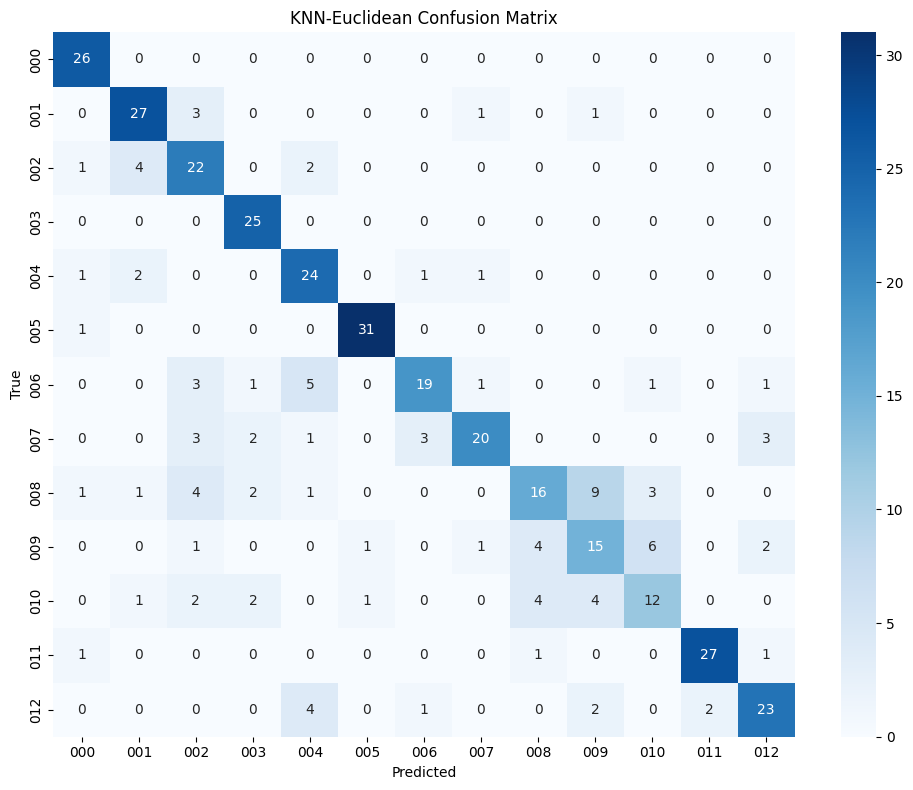


🔸 KNN-Cosine Results:
✅ Accuracy: 0.7110
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.76      0.96      0.85        26
         001       0.71      0.84      0.77        32
         002       0.54      0.76      0.63        29
         003       0.81      1.00      0.89        25
         004       0.67      0.83      0.74        29
         005       0.94      1.00      0.97        32
         006       0.78      0.58      0.67        31
         007       0.83      0.59      0.69        32
         008       0.54      0.41      0.46        37
         009       0.52      0.40      0.45        30
         010       0.43      0.38      0.41        26
         011       0.96      0.90      0.93        30
         012       0.73      0.69      0.71        32

    accuracy                           0.71       391
   macro avg       0.71      0.72      0.71       391
weighted avg       0.71      0.71      0.70       391



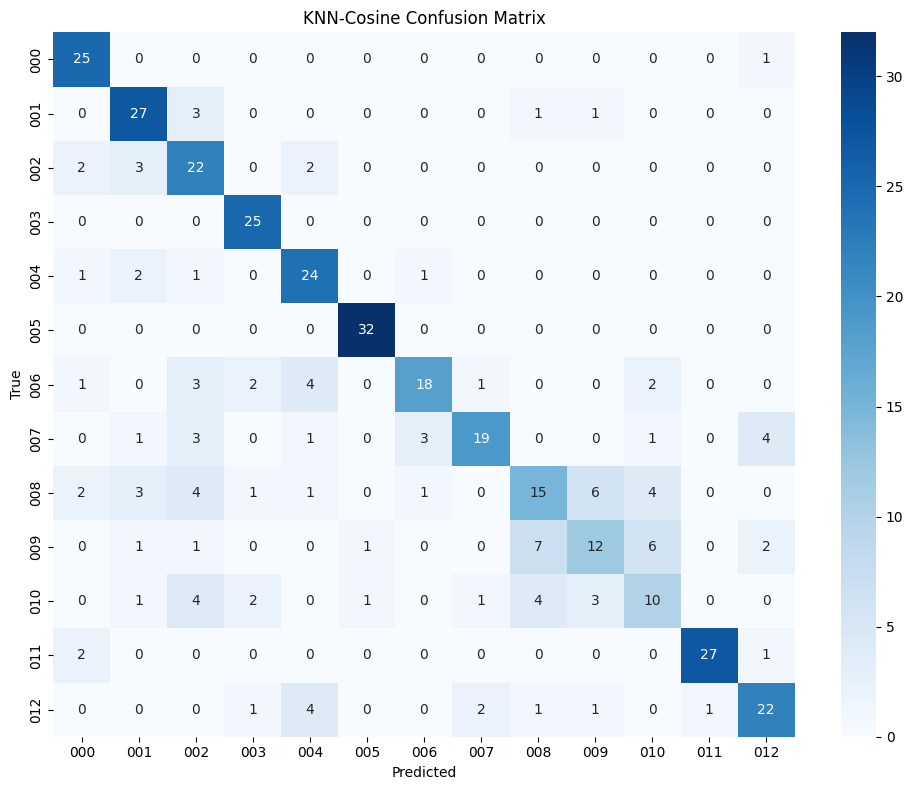


🔸 Logistic-Euclidean Results:
✅ Accuracy: 0.8824
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.96      0.96      0.96        26
         001       0.94      0.97      0.95        32
         002       0.93      0.93      0.93        29
         003       0.96      1.00      0.98        25
         004       0.97      0.97      0.97        29
         005       0.94      0.97      0.95        32
         006       1.00      0.81      0.89        31
         007       1.00      0.97      0.98        32
         008       0.82      0.62      0.71        37
         009       0.57      0.70      0.63        30
         010       0.66      0.73      0.69        26
         011       0.91      0.97      0.94        30
         012       0.91      0.94      0.92        32

    accuracy                           0.88       391
   macro avg       0.89      0.89      0.89       391
weighted avg       0.89      0.88      0.88       391



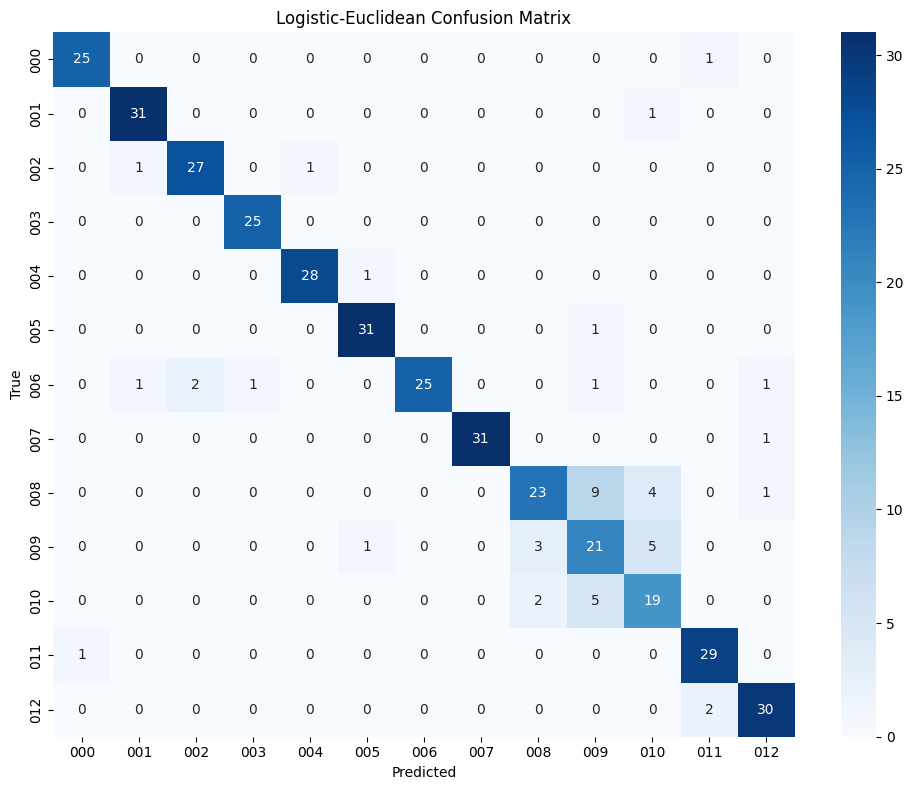


🔸 Logistic-Cosine Results:
✅ Accuracy: 0.6522
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.80      0.92      0.86        26
         001       0.76      0.78      0.77        32
         002       0.59      0.83      0.69        29
         003       0.74      1.00      0.85        25
         004       0.59      0.69      0.63        29
         005       0.79      0.81      0.80        32
         006       0.53      0.52      0.52        31
         007       1.00      0.50      0.67        32
         008       0.60      0.24      0.35        37
         009       0.50      0.33      0.40        30
         010       0.42      0.50      0.46        26
         011       0.69      0.97      0.81        30
         012       0.56      0.56      0.56        32

    accuracy                           0.65       391
   macro avg       0.66      0.67      0.64       391
weighted avg       0.66      0.65      0.64       391



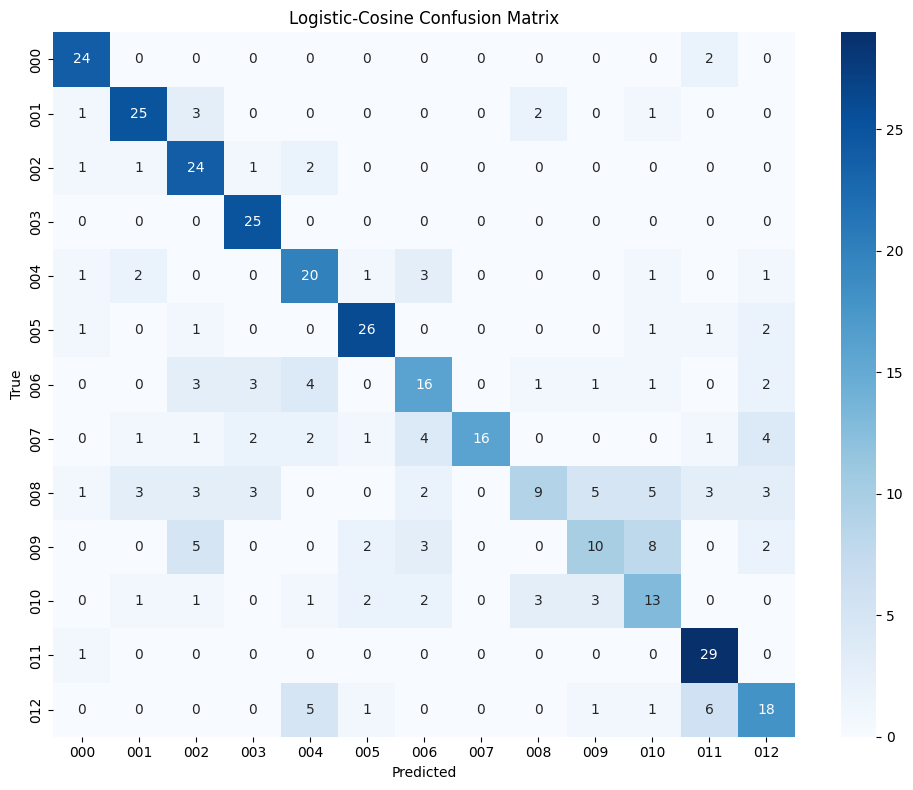


🔸 SVM-Euclidean Results:
✅ Accuracy: 0.9079
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.96      1.00      0.98        26
         001       0.97      1.00      0.98        32
         002       0.97      0.97      0.97        29
         003       1.00      1.00      1.00        25
         004       0.93      0.93      0.93        29
         005       0.94      1.00      0.97        32
         006       1.00      0.87      0.93        31
         007       0.94      1.00      0.97        32
         008       0.76      0.70      0.73        37
         009       0.67      0.73      0.70        30
         010       0.73      0.73      0.73        26
         011       1.00      0.97      0.98        30
         012       0.97      0.94      0.95        32

    accuracy                           0.91       391
   macro avg       0.91      0.91      0.91       391
weighted avg       0.91      0.91      0.91       391



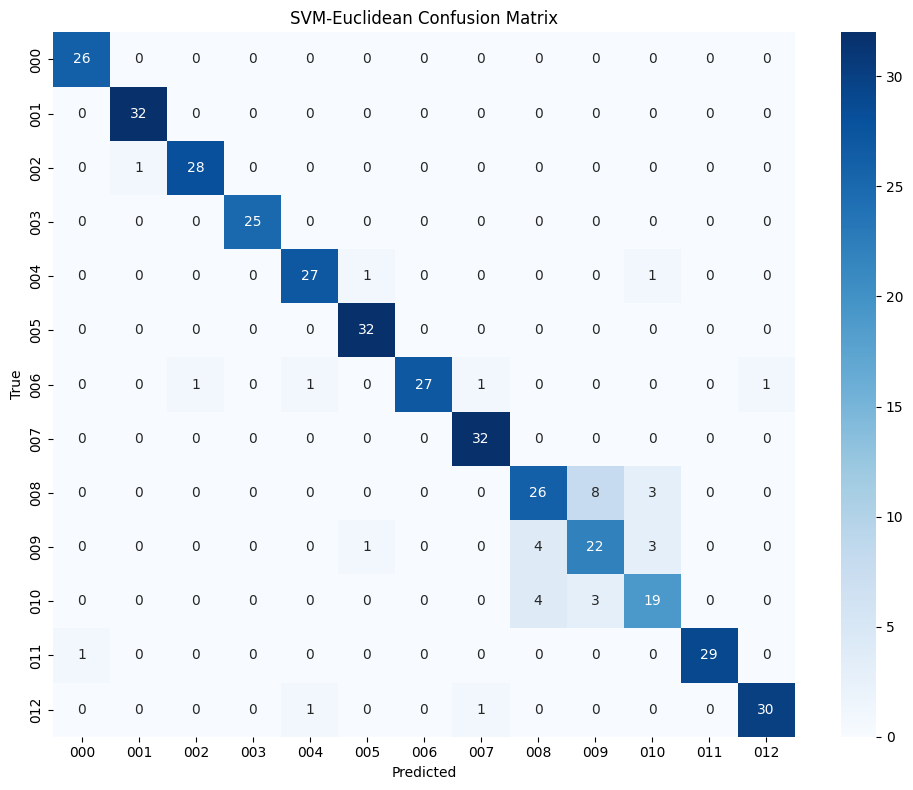


🔸 SVM-Cosine Results:
✅ Accuracy: 0.7059
📊 Classification Report:
              precision    recall  f1-score   support

         000       0.93      0.96      0.94        26
         001       0.86      0.78      0.82        32
         002       0.74      0.86      0.79        29
         003       0.86      1.00      0.93        25
         004       0.69      0.83      0.75        29
         005       0.88      0.91      0.89        32
         006       0.58      0.71      0.64        31
         007       0.81      0.53      0.64        32
         008       0.72      0.35      0.47        37
         009       0.38      0.37      0.37        30
         010       0.32      0.42      0.37        26
         011       0.85      0.93      0.89        30
         012       0.68      0.66      0.67        32

    accuracy                           0.71       391
   macro avg       0.71      0.72      0.71       391
weighted avg       0.72      0.71      0.70       391



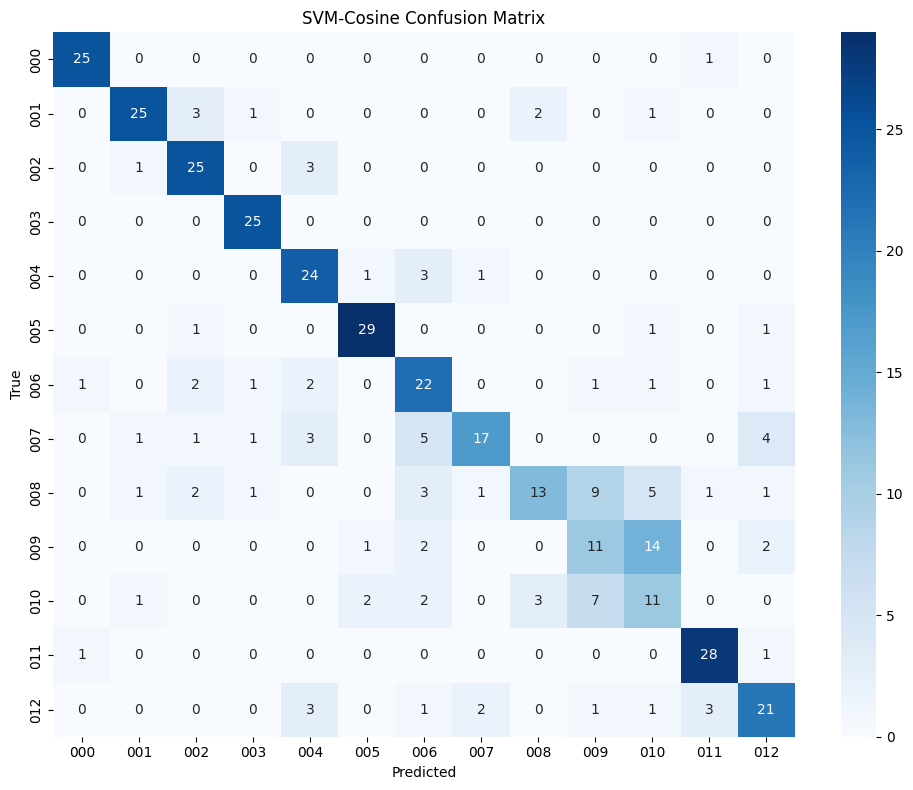

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import normalize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Normalize embeddings for cosine classifiers
train_embeddings_cos = normalize(train_embeddings.numpy(), axis=1)
test_embeddings_cos = normalize(all_embeddings.numpy(), axis=1)
train_embeddings_euc = train_embeddings.numpy()
test_embeddings_euc = all_embeddings.numpy()

# Classifiers config
classifiers = {
    "KNN-Euclidean": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN-Cosine": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
    "Logistic-Euclidean": LogisticRegression(max_iter=1000),
    "Logistic-Cosine": LogisticRegression(max_iter=1000),
    "SVM-Euclidean": SVC(kernel="linear"),
    "SVM-Cosine": SVC(kernel="linear"),
}

# Create results directory
os.makedirs("results", exist_ok=True)

for name, clf in classifiers.items():
    print(f"\n🔸 {name} Results:")

    if "Cosine" in name:
        clf.fit(train_embeddings_cos, train_labels)
        preds = clf.predict(test_embeddings_cos)
    else:
        clf.fit(train_embeddings_euc, train_labels)
        preds = clf.predict(test_embeddings_euc)

    acc = accuracy_score(all_labels, preds)
    print(f"✅ Accuracy: {acc:.4f}")
    print("📊 Classification Report:")
    print(classification_report(all_labels, preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"results/confusion_matrix_{name.replace(' ', '_')}.png", dpi=300)
    plt.close()
